# PSD of Streamwise Velocity at 10, 20 and 50 m

This notebook computes and plots the Power Spectral Density (PSD) of the streamwise velocity component (`ux`) at three heights extracted from a line probe.

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Load data

In [43]:
points_path = "fixtures/line.line_profile line.points.csv"
ux_path     = "fixtures/line.line_profile line.ux.csv"

df_pts = pd.read_csv(points_path, index_col="idx")
df_ux  = pd.read_csv(ux_path)
time_steps = df_ux["time_step"].to_numpy(dtype=np.float32)
df_ux.drop(columns=("time_step"), inplace=True)

# Column names in df_ux are strings; cast to int for easy indexing
df_ux.columns = df_ux.columns.astype(int)

print(f"Points shape: {df_pts.shape}")
print(f"Velocity shape: {df_ux.shape}  (time steps x probe points)")
print(f"z range: {df_pts['z'].min():.1f} - {df_pts['z'].max():.1f} m")

Points shape: (201, 3)
Velocity shape: (7447, 201)  (time steps x probe points)
z range: 0.0 - 200.0 m


## Select probe points closest to 10, 20 and 50 m

In [44]:
target_heights = [10, 20, 50]  # metres

selected = {}
for z_target in target_heights:
    idx = (df_pts["z"] - z_target).abs().idxmin()
    z_actual = df_pts.loc[idx, "z"]
    selected[z_target] = {"idx": idx, "z_actual": z_actual}
    print(f"z = {z_target:>3} m  ->  point idx {idx:>3}, z_actual = {z_actual:.4f} m")

z =  10 m  ->  point idx  10, z_actual = 10.0000 m
z =  20 m  ->  point idx  20, z_actual = 20.0000 m
z =  50 m  ->  point idx  50, z_actual = 50.0000 m


## Estimate sampling frequency

In [45]:
dt = time_steps[1] - time_steps[0]
fs = 1.0 / dt
print(f"Mean dt = {dt:.6f} s  ->  fs = {fs:.3f} Hz")

Mean dt = 0.080582 s  ->  fs = 12.410 Hz


## Compute PSD

The PSD is computed using a periodogram with Gaussian smoothing (sigma=3) and normalized to
dimensionless wind-engineering form: x-axis N = f * z / U, y-axis N * Suu / sigma^2.

In [46]:
import scipy
from scipy.ndimage import gaussian_filter

def spectral_density_function(
    velocity_signal: np.ndarray,
    timestamps: np.ndarray,
    reference_velocity: float,
    characteristic_length: float,
) -> tuple[np.ndarray, np.ndarray]:
    """Perform a FFT over a velocity signal

    Args:
        velocity_signal (np.ndarray): Array of instantaneous velocity signal
        timestamps (np.ndarray): Array of timestamps of the signal
        reference_velocity (float): Value for reference velocity. For normalization
        characteristic_length (float): Value for Characteristic length. For normalization

    Returns:
        tuple[np.ndarray, np.ndarray]: Tuple with spectral density values array and normalized frequency values array
    """

    def filter_avg_data(data: np.ndarray) -> np.ndarray:
        filtered_data = gaussian_filter(data, sigma=3)  # Sigma smooths the curve
        return filtered_data

    delta_t = timestamps[1] - timestamps[0]
    signal_frequency = 1 / delta_t

    (xf, yf) = scipy.signal.periodogram(velocity_signal, signal_frequency, scaling="density")
    st = np.std(velocity_signal)
    yf = xf * yf / st**2
    xf = xf * characteristic_length / reference_velocity  # Stroulhall number N = f * L / U

    # Get the filter coefficients so we can check its frequency response.
    yf = filter_avg_data(yf)
    return xf[2:], yf[2:]


In [47]:
psd_results = {}
for z_target, info in selected.items():
    u = df_ux[info["idx"]].to_numpy(dtype=float)
    u_mean = u.mean()
    u_std = u.std()
    xf, yf = spectral_density_function(
        velocity_signal=u,
        timestamps=time_steps,
        reference_velocity=u_mean,
        characteristic_length=z_target,
    )
    df_freq = pd.DataFrame({"freq_x": xf, "psd_y": yf})
    df_freq.to_csv(f"psd_{z_target}m.csv", index=False)
    psd_results[z_target] = (xf, yf)
    print(f"z = {z_target:>3} m  |  u_mean = {u_mean:.3f} m/s  |  u_std = {u_std:.3f} m/s")

z =  10 m  |  u_mean = 21.442 m/s  |  u_std = 3.671 m/s
z =  20 m  |  u_mean = 23.254 m/s  |  u_std = 3.630 m/s
z =  50 m  |  u_mean = 25.853 m/s  |  u_std = 3.707 m/s


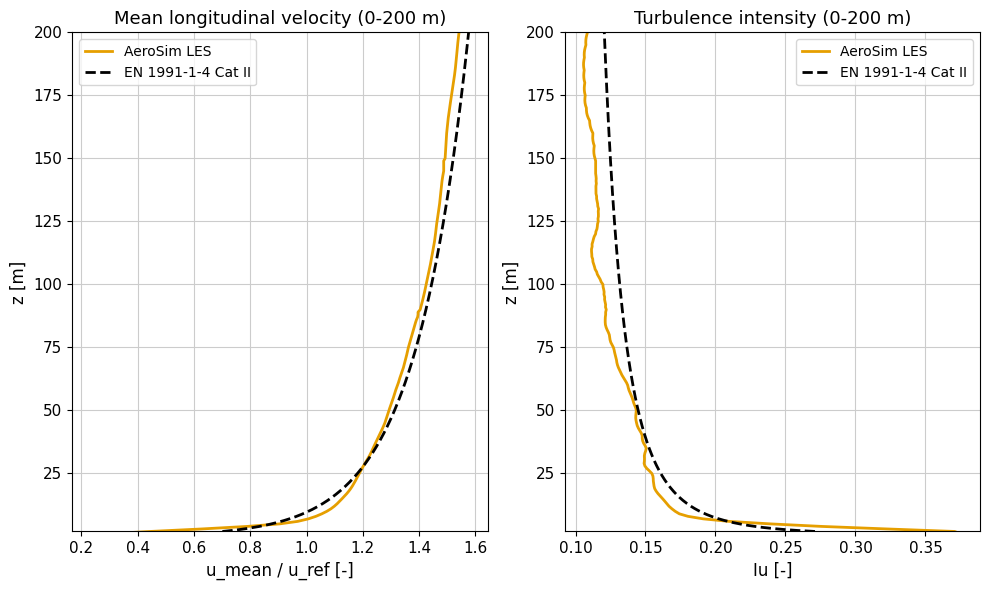

In [50]:
# Eurocode EN 1991-1-4, Terrain Category II
z0_cat2 = 0.05    # roughness length [m]
z_min_cat2 = 2.0  # minimum height [m]
kr_cat2 = 0.19    # roughness factor (= 0.19 * (z0/z0_II)^0.07, with z0_II = 0.05 m)

z_ec = np.linspace(z_min_cat2, 200, 500)
u_ec_norm = kr_cat2 * np.log(z_ec / z0_cat2)  # u(z)/u_ref, assuming vb = u_ref
Iu_ec = 1.0 / np.log(z_ec / z0_cat2)           # Iv(z) = kI / (c0 * ln(z/z0)), kI=c0=1

u_mean = df_ux.mean(axis=0).to_numpy()
u_ref = 20
u_rms = df_ux.std(axis=0).to_numpy()
z = df_pts["z"].to_numpy()

# Style constants (AeroSim docs style)
SIM_COLOR  = "#e69f00"
REF_COLOR  = "#000000"
GRID_COLOR = "#cccccc"
LW = 2.0

fig, ax = plt.subplots(1, 2, figsize=(10, 6))

for a in ax:
    a.set_facecolor("#ffffff")
    a.grid(True, color=GRID_COLOR, linewidth=0.8, linestyle="-")
    a.set_ylim(2, 200)
    a.tick_params(labelsize=11)

# Velocity profile
ax[0].plot(u_mean / u_ref, z,
           color=SIM_COLOR, linewidth=LW, label="AeroSim LES")
ax[0].plot(u_ec_norm, z_ec,
           color=REF_COLOR, linewidth=LW, linestyle="--", label="EN 1991-1-4 Cat II")
ax[0].set_xlabel("u_mean / u_ref [-]", fontsize=12)
ax[0].set_ylabel("z [m]", fontsize=12)
ax[0].set_title("Mean longitudinal velocity (0-200 m)", fontsize=13)
ax[0].legend(fontsize=10)

# Turbulence intensity
ax[1].plot(u_rms / u_mean, z,
           color=SIM_COLOR, linewidth=LW, label="AeroSim LES")
ax[1].plot(Iu_ec, z_ec,
           color=REF_COLOR, linewidth=LW, linestyle="--", label="EN 1991-1-4 Cat II")
ax[1].set_xlabel("Iu [-]", fontsize=12)
ax[1].set_ylabel("z [m]", fontsize=12)
ax[1].set_title("Turbulence intensity (0-200 m)", fontsize=13)
ax[1].legend(fontsize=10)

fig.tight_layout()
plt.show()

## Plot PSD

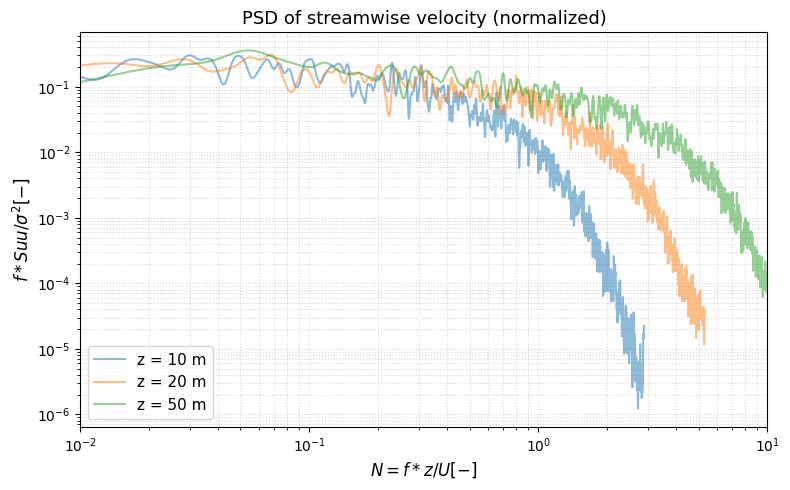

Figure saved as psd_velocity.png


In [49]:
colors = ["tab:blue", "tab:orange", "tab:green"]

fig, ax = plt.subplots(figsize=(8, 5))

for (z_target, (xf, yf)), color in zip(psd_results.items(), colors):
    ax.loglog(xf, yf, label=f"z = {z_target} m", color=color, linewidth=1.5, alpha=0.5)

ax.set_xlabel(r"$N = f * z / U [-]$", fontsize=12)
ax.set_ylabel(r"$f * Suu / \sigma^2 [-]$", fontsize=12)
ax.set_title("PSD of streamwise velocity (normalized)", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, which="both", linestyle=":", alpha=0.5)
ax.set_xlim(1e-2, 10)

plt.tight_layout()
plt.savefig("psd_velocity.png", dpi=150)
plt.show()
print("Figure saved as psd_velocity.png")